#### 1) Import libraries

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


#### 2) Import the Lpxc dataset

In [10]:
df= pd.read_csv(r"C:\Users\DELL\Documents\Subodh\Lpxc_inhibitors_Pa.csv")
df.head(45)

,Sr.No,Class,SMILES,MIC (ug/mL),IC50(nM),pIC50,pMIC
0,1,sulfonamides1,O=C(N[C@@H](C(NS(=O)(C)=O)(C)C)C(NO)=O)C(C=C1)...,1.0,6.1,8.2,8.6
1,2,sulfonamides2,O=C(N[C@@H](C(NS(=O)(C)=O)(C)C)C(NO)=O)C(C=C1)...,0.5,10.1,8.0,9.0
2,3,CHIR-090,O=C(N[C@@H]([C@H](O)C)C(NO)=O)C1=CC=C(C#CC2=CC...,0.5,9.8,8.0,8.9
3,4,LPC-009,C[C@H](O)[C@@H](NC(C1=CC=C(C#CC#CC2=CC=CC=C2)C...,0.7,9.3,8.0,8.7
4,5,LPC-011,C[C@H](O)[C@@H](NC(C1=CC=C(C#CC#CC2=CC=C(N)C=C...,0.3,7.3,8.1,9.1
5,6,LPC-051,O=C(N[C@@H]([C@](O)(C)C1=CC=C(O)C=C1)C(NO)=O)C...,0.7,4.3,8.4,8.8
6,7,LPC-058,O=C(N[C@@H]([C@](O)(C(F)(F)F)C)C(NO)=O)C1=CC=C...,0.2,3.9,8.4,9.4
7,8,LPC-069,ONC(C([C@](C(F)F)(C)O)CC(C(C=C1)=CC=C1C#CC2=CC...,3.2,11.3,7.9,8.2
8,9,LPC-233,O=C(N[C@H](C(NO)=O)[C@](O)(C(F)(F)F)C)C1=CC=C(...,0.5,2.8,8.6,8.9
9,10,STR20,ONC(C(CC(N)=O)NC(C1=CC=C(C#CC2=CC=CC=C2)C=C1)=...,0.5,4.4,8.4,8.9


#### 3) Validate and clean SMILES

In [17]:
from rdkit import Chem

df["mol"] = df["SMILES"].apply(Chem.MolFromSmiles)
df = df[df["mol"].notna()].reset_index(drop=True)
df.head()

,Sr.No,Class,SMILES,MIC (ug/mL),IC50(nM),pIC50,pMIC,mol,scaffold
0,1,sulfonamides1,O=C(N[C@@H](C(NS(=O)(C)=O)(C)C)C(NO)=O)C(C=C1)...,1.0,6.1,8.2,8.6,<rdkit.Chem.rdchem.Mol object at 0x000001A6125...,c1ccc(-c2ccccc2)cc1
1,2,sulfonamides2,O=C(N[C@@H](C(NS(=O)(C)=O)(C)C)C(NO)=O)C(C=C1)...,0.5,10.1,8.0,9.0,<rdkit.Chem.rdchem.Mol object at 0x000001A6145...,c1ccc(-c2cc3cc4c(cc3o2)OCO4)cc1
2,3,CHIR-090,O=C(N[C@@H]([C@H](O)C)C(NO)=O)C1=CC=C(C#CC2=CC...,0.5,9.8,8.0,8.9,<rdkit.Chem.rdchem.Mol object at 0x000001A6145...,C(#Cc1ccc(CN2CCOCC2)cc1)c1ccccc1
3,4,LPC-009,C[C@H](O)[C@@H](NC(C1=CC=C(C#CC#CC2=CC=CC=C2)C...,0.7,9.3,8.0,8.7,<rdkit.Chem.rdchem.Mol object at 0x000001A6145...,C(C#Cc1ccccc1)#Cc1ccccc1
4,5,LPC-011,C[C@H](O)[C@@H](NC(C1=CC=C(C#CC#CC2=CC=C(N)C=C...,0.3,7.3,8.1,9.1,<rdkit.Chem.rdchem.Mol object at 0x000001A6145...,C(C#Cc1ccccc1)#Cc1ccccc1


#### 4) Compute molecular fingerprints + descriptors

In [13]:
import numpy as np
from rdkit.Chem import AllChem, Descriptors

def featurize(mol):
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
    arr = np.array(fp)
    desc = [
        Descriptors.MolWt(mol),
        Descriptors.MolLogP(mol),
        Descriptors.NumHDonors(mol),
        Descriptors.NumHAcceptors(mol),
        Descriptors.TPSA(mol),
        Descriptors.NumRotatableBonds(mol)
    ]
    return np.concatenate([arr, desc])

X = np.vstack(df["mol"].apply(featurize))
y_pMIC = df["pMIC"].values
y_pIC50 = df["pIC50"].values

#### 5) Generate Murcko scaffolds (for scaffold split)

In [16]:
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit import Chem




### 3) Distribution Graph


sns.set(style="whitegrid")

plt.figure(figsize=(8, 6))
sns.histplot(df["pIC50"], bins=20, kde=True, color="blue")
plt.title("Distribution of pIC50 Values", fontsize=16)
plt.xlabel("pIC50", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.show()


### 4) Define a Threshold

### 5) Active vs Inactive Distribution

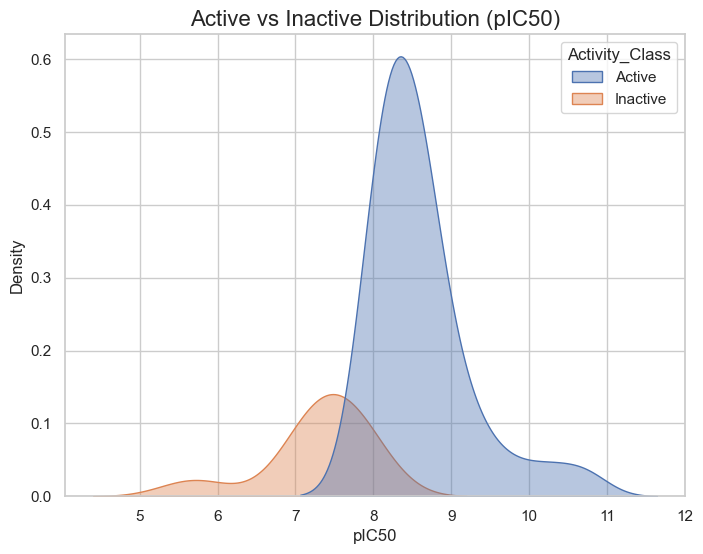

In [17]:
plt.figure(figsize=(8, 6))
sns.kdeplot(data=df, x="pIC50", hue="Activity_Class", fill=True, alpha=0.4)
plt.title("Active vs Inactive Distribution (pIC50)", fontsize=16)
plt.show()


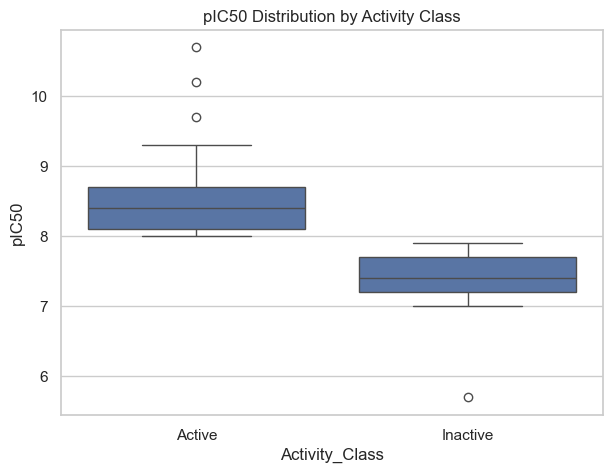

In [18]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="Activity_Class", y="pIC50")
plt.title("pIC50 Distribution by Activity Class")
plt.show()


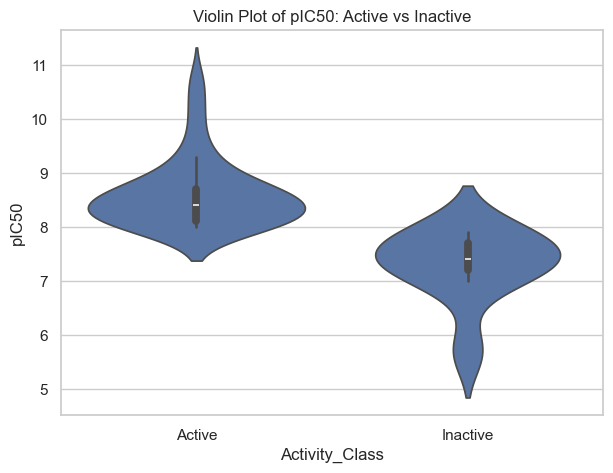

In [19]:
plt.figure(figsize=(7, 5))
sns.violinplot(data=df, x="Activity_Class", y="pIC50")
plt.title("Violin Plot of pIC50: Active vs Inactive")
plt.show()


In [22]:
def classify_activity(row):
    if row["pIC50"] >= 8 or row["IC50(nM)"] <= 10:
        return "Active"
    else:
        return "Inactive"

df["Activity_Class"] = df.apply(classify_activity, axis=1)

df["Activity_Class"].value_counts()


Activity_Class
Active      33
Inactive     9
Name: count, dtype: int64

In [24]:
active_df = df[df["Activity_Class"] == "Active"]
inactive_df = df[df["Activity_Class"] == "Inactive"]

print("Active compounds:", active_df.shape[0])
print("Inactive compounds:", inactive_df.shape[0])


Active compounds: 33
Inactive compounds: 9


### Actives pIC50>8

In [26]:
active_df = df[df["Activity_Class"] == "Active"]
print("Active Compounds Table:")
display(active_df)


Active Compounds Table:


,Sr.No,Class,SMILES,MIC (ug/mL),IC50(nM),pIC50,pMIC,Activity_Class
0,1,sulfonamides1,O=C(N[C@@H](C(NS(=O)(C)=O)(C)C)C(NO)=O)C(C=C1)...,1.0,6.1,8.2,8.6,Active
1,2,sulfonamides2,O=C(N[C@@H](C(NS(=O)(C)=O)(C)C)C(NO)=O)C(C=C1)...,0.5,10.1,8.0,9.0,Active
2,3,CHIR-090,O=C(N[C@@H]([C@H](O)C)C(NO)=O)C1=CC=C(C#CC2=CC...,0.5,9.8,8.0,8.9,Active
3,4,LPC-009,C[C@H](O)[C@@H](NC(C1=CC=C(C#CC#CC2=CC=CC=C2)C...,0.7,9.3,8.0,8.7,Active
4,5,LPC-011,C[C@H](O)[C@@H](NC(C1=CC=C(C#CC#CC2=CC=C(N)C=C...,0.3,7.3,8.1,9.1,Active
5,6,LPC-051,O=C(N[C@@H]([C@](O)(C)C1=CC=C(O)C=C1)C(NO)=O)C...,0.7,4.3,8.4,8.8,Active
6,7,LPC-058,O=C(N[C@@H]([C@](O)(C(F)(F)F)C)C(NO)=O)C1=CC=C...,0.2,3.9,8.4,9.4,Active
8,9,LPC-233,O=C(N[C@H](C(NO)=O)[C@](O)(C(F)(F)F)C)C1=CC=C(...,0.5,2.8,8.6,8.9,Active
9,10,STR20,ONC(C(CC(N)=O)NC(C1=CC=C(C#CC2=CC=CC=C2)C=C1)=...,0.5,4.4,8.4,8.9,Active
10,11,STR21,ONC([C@H](CC(NCCCO)=O)NC(C1=CC=C(C#CC2=CC=CC=C...,0.6,5.3,8.3,8.9,Active


### Inactives pIC50<8

In [27]:
inactive_df = df[df["Activity_Class"] == "Inactive"]
print("Inactive Compounds Table:")
display(inactive_df)


Inactive Compounds Table:


,Sr.No,Class,SMILES,MIC (ug/mL),IC50(nM),pIC50,pMIC,Activity_Class
7,8,LPC-069,ONC(C([C@](C(F)F)(C)O)CC(C(C=C1)=CC=C1C#CC2=CC...,3.2,11.3,7.9,8.2,Inactive
11,12,STR22,ONC([C@H](CC(NCCOC)=O)NC(C1=CC=C(C#CC2=CC=CC=C...,0.6,33.0,7.5,8.9,Inactive
12,13,STR23,ONC([C@H](CC(NCC#C)=O)NC(C1=CC=C(C#CC2=CC=CC=C...,0.5,14.0,7.9,8.9,Inactive
32,33,STR65,O=C(N1[C@H](C(Cl)=O)CCCC1)C2=CC=C(C#CC3=CC=C(C...,128.0,2000.0,5.7,6.7,Inactive
35,36,STR68,O[C@@H](C)C1=NC=CN1CC2=NOC(C#CC3=CC=C(OCC(CO)(...,4.0,53.4,7.3,8.0,Inactive
36,37,TP058653_STR 69,O[C@@H](C)C1=NC=CN1CC2=NOC(C#CC3=CC=C(C#C[C@@H...,4.0,101.0,7.0,8.1,Inactive
37,38,Imidazole-basedA,C[C@H](O)C1=NC=CN1CC#CC2=CC=C(C=C2)C3=CC=C(C4C...,2.0,56.8,7.2,8.3,Inactive
38,39,Imidazole-basedB,C[C@H](O)C1NC=CN1C/C=C/C2=CC=C(C=C2)C3=CC=C(O[...,2.0,38.2,7.4,8.3,Inactive
40,41,STR72 A,O=CN(O)CCCC1=CC=C(C#CC2=CC=C(CN3CCOCC3)C=C2)C=C1,8.8,21.0,7.7,7.6,Inactive
